In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# Show first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [3]:
# Missing values
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [4]:
# Check duplicates
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

0


In [5]:
# Rename columns
df.columns = df.columns.str.replace(" ", "_")

print(df.columns)

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


In [6]:
# Create average score
df['average_score'] = (
    df['math_score'] +
    df['reading_score'] +
    df['writing_score']
) / 3

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [7]:
# Statistical summary
df.describe()

,math_score,reading_score,writing_score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


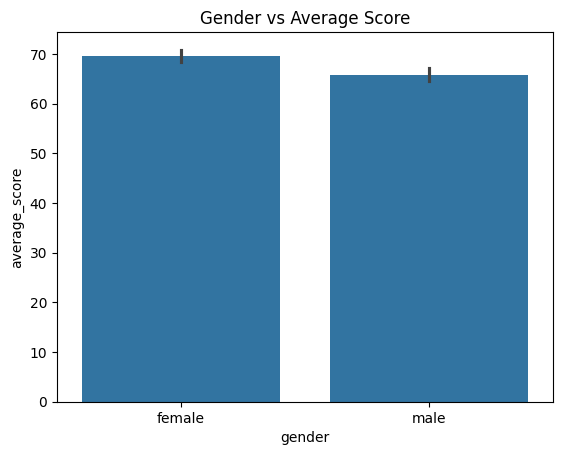

In [8]:
sns.barplot(x='gender', y='average_score', data=df)

plt.title("Gender vs Average Score")

plt.show()

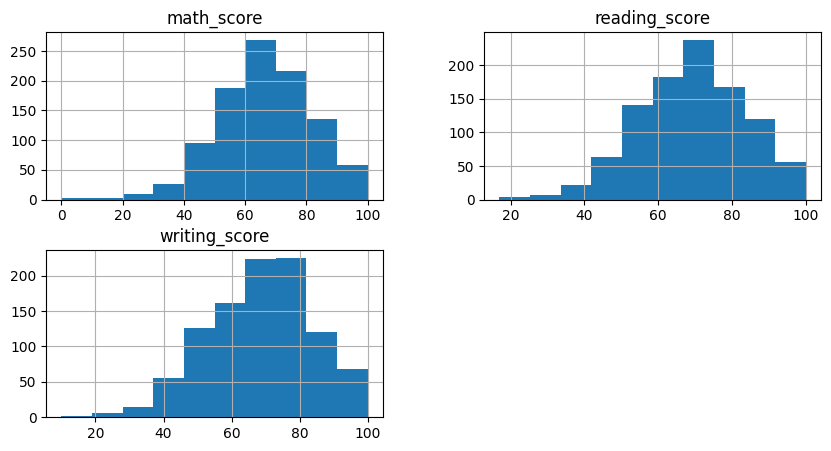

In [9]:
df[['math_score','reading_score','writing_score']].hist(figsize=(10,5))

plt.show()

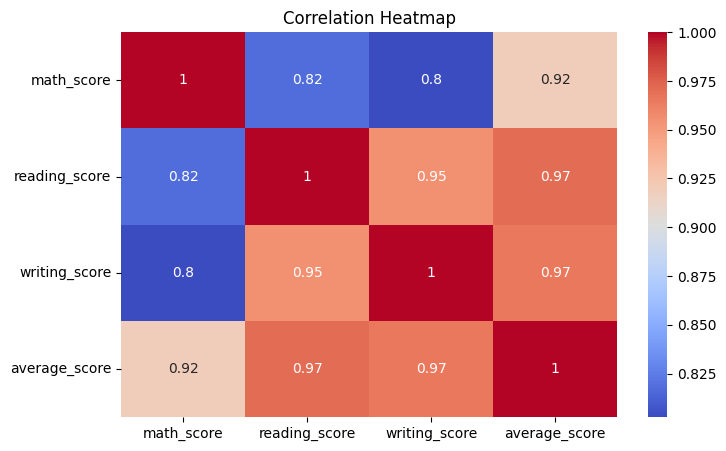

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,5))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

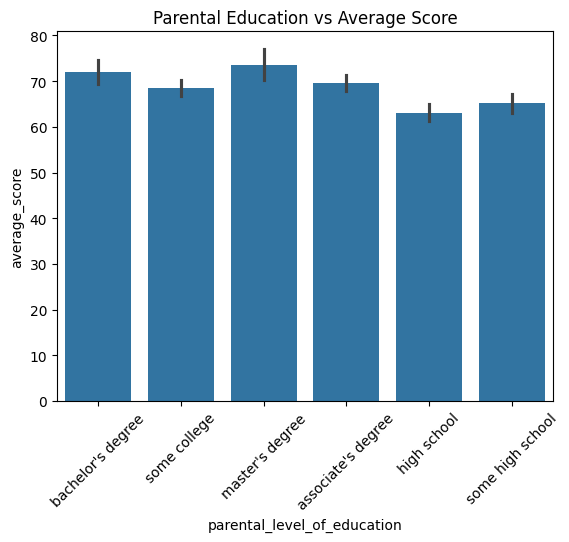

In [11]:
sns.barplot(
    x='parental_level_of_education',
    y='average_score',
    data=df
)

plt.xticks(rotation=45)

plt.title("Parental Education vs Average Score")

plt.show()

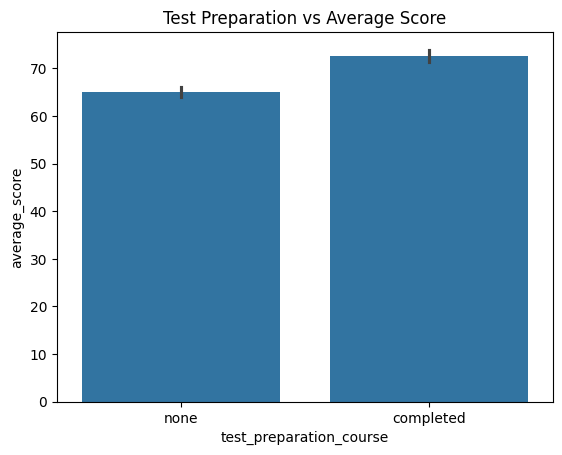

In [12]:
sns.barplot(
    x='test_preparation_course',
    y='average_score',
    data=df
)

plt.title("Test Preparation vs Average Score")

plt.show()

In [13]:
def performance(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Average"

    else:
        return "Poor"

df['Performance_Level'] = df['average_score'].apply(performance)

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,Performance_Level
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Good
1,female,group C,some college,standard,completed,69,90,88,82.333333,Excellent
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Average
4,male,group C,some college,standard,none,76,78,75,76.333333,Good


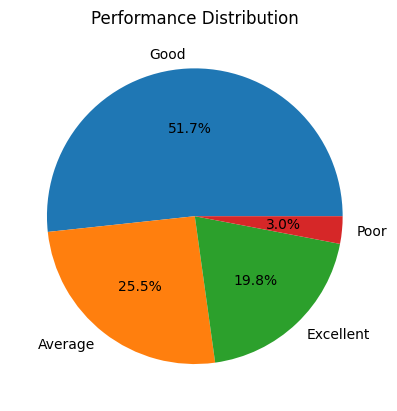

In [14]:
df['Performance_Level'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Performance Distribution")

plt.ylabel("")

plt.show()

In [15]:
df.to_csv("cleaned_student_data.csv", index=False)